In [90]:
using ITensors
using ITensorMPS
using JLD2
using Plots
using LaTeXStrings
using Printf
using Polynomials




In [91]:
using JLD2
using Printf

data_dir = joinpath(@__DIR__, "data_new")

# all_data[truncation][sigma] = loaded_data_dict 
all_data = Dict{Float64, Dict{Float64, Any}}() 

# sigma_values = [0.0, 5e-7, 6e-7, 7e-7, 8e-7, 9e-7, 1e-6, 2e-6, 3e-6, 4e-6, 5e-6, 1e-5, 1e-4, 1e-3, 1e-2, 2e-2, 1e-1, 2e-1, 5e-1, 7e-1, 1.0, 1.5, 2.0, 3.0, 5.0]
sigma_values = [0.0, 5e-7, 6e-7, 7e-7, 8e-7, 9e-7, 1e-6, 1.2e-6, 1.4e-6, 1.6e-6, 1.8e-6, 2e-6, 2.2e-6, 2.4e-6, 2.6e-6, 2.8e-6, 3e-6, 4e-6, 5e-6, 1e-5, 1e-4, 1e-3, 1e-2, 2e-2, 1e-1, 2e-1, 5e-1, 7e-1, 1.0, 1.5, 2.0, 3.0, 5.0]
sigma_values_with_spike = [0.0, 5e-7, 6e-7, 7e-7, 8e-7, 9e-7, 1e-6, 1.2e-6, 1.4e-6, 1.6e-6, 1.8e-6, 2e-6, 2.2e-6, 2.4e-6, 2.6e-6, 2.8e-6, 3e-6]
trunc_values = [1e-16, 1e-15, 1e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8] 

for trunc in trunc_values
    all_data[trunc] = Dict{Float64, Any}()
    
    for σ in sigma_values
        trunc_str = @sprintf("%.1e", trunc)
        
        # Explicitly format the clean case string to match the get_data_clean.jl output
        if σ == 0.0
            sigma_str = "0.0e+00"
        else
            sigma_str = @sprintf("%.1e", σ)
        end

        file_name = "data_fid_$(trunc_str)_$(sigma_str).jld2" 
        file_path = joinpath(data_dir, file_name) 
        
        if isfile(file_path) 
            try
                data = load(file_path)
                all_data[trunc][σ] = data 
                println("Successfully loaded: Trunc=$trunc_str, σ=$sigma_str")
            catch e
                println("ERROR loading file: $file_name -> $e")
            end
        else
            println("File not found: $file_name") 
        end
    end
end


Successfully loaded: Trunc=1.0e-16, σ=0.0e+00
Successfully loaded: Trunc=1.0e-16, σ=5.0e-07
Successfully loaded: Trunc=1.0e-16, σ=6.0e-07
Successfully loaded: Trunc=1.0e-16, σ=7.0e-07
Successfully loaded: Trunc=1.0e-16, σ=8.0e-07
Successfully loaded: Trunc=1.0e-16, σ=9.0e-07
Successfully loaded: Trunc=1.0e-16, σ=1.0e-06
Successfully loaded: Trunc=1.0e-16, σ=1.2e-06
Successfully loaded: Trunc=1.0e-16, σ=1.4e-06
Successfully loaded: Trunc=1.0e-16, σ=1.6e-06
Successfully loaded: Trunc=1.0e-16, σ=1.8e-06
Successfully loaded: Trunc=1.0e-16, σ=2.0e-06
Successfully loaded: Trunc=1.0e-16, σ=2.2e-06
Successfully loaded: Trunc=1.0e-16, σ=2.4e-06
Successfully loaded: Trunc=1.0e-16, σ=2.6e-06
Successfully loaded: Trunc=1.0e-16, σ=2.8e-06
Successfully loaded: Trunc=1.0e-16, σ=3.0e-06
Successfully loaded: Trunc=1.0e-16, σ=4.0e-06
Successfully loaded: Trunc=1.0e-16, σ=5.0e-06
Successfully loaded: Trunc=1.0e-16, σ=1.0e-05
Successfully loaded: Trunc=1.0e-16, σ=1.0e-04
Successfully loaded: Trunc=1.0e-16

In [92]:
println(all_data[1e-16][1e-6]["avg_arr"])

[2.0, 3.9, 7.6, 13.1, 19.6, 25.2, 32.7, 38.8, 44.8, 49.9, 52.1, 56.9, 53.8, 53.6, 54.4, 51.6, 45.8, 37.2, 32.9, 24.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


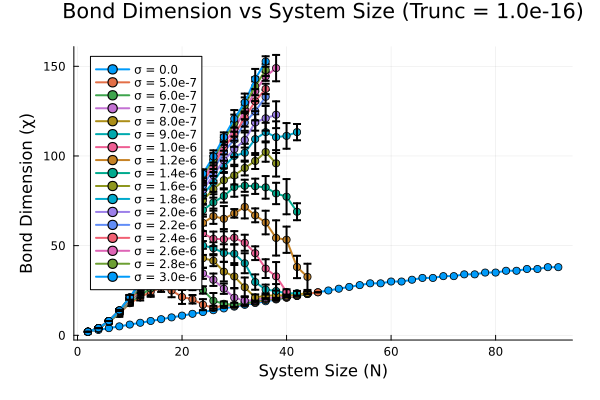

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\bd.png"

In [93]:
target_sigmas = union([0.0], sigma_values_with_spike)
target_trunc = 1e-16

p_bd = plot(
    title = "Bond Dimension vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topleft,    
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    # Flipped to match the new all_data[truncation][sigma] structure
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        bond_dims_full = data["avg_arr"]
        err_arr_full = data["err_arr"]
        
        mask = bond_dims_full .> 0
        N_vals = N_full[mask]
        bond_dims = bond_dims_full[mask]
        
        if σ == 0.0
            err_bars = nothing
        else
            err_bars = err_arr_full[mask]
        end

        plot!(p_bd, N_vals, bond_dims, 
            yerror = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_bd)
savefig(p_bd, joinpath("images", "bd.png"))

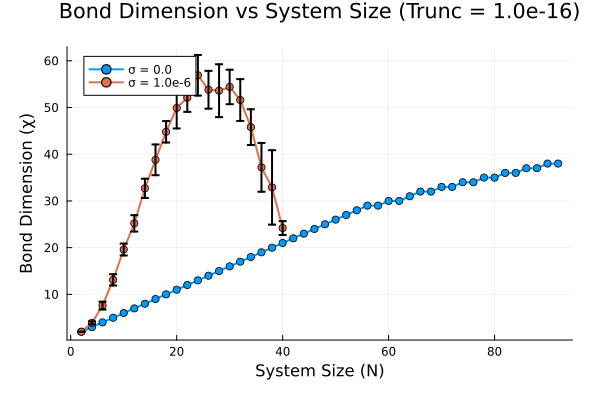

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\bd_some.png"

In [94]:
target_sigmas = [0.0, 1e-6] 
target_trunc = 1e-16

p_bd = plot(
    title = "Bond Dimension vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topleft,    
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    # Flipped to match the new all_data[truncation][sigma] structure
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        bond_dims_full = data["avg_arr"]
        err_arr_full = data["err_arr"]
        
        mask = bond_dims_full .> 0
        N_vals = N_full[mask]
        bond_dims = bond_dims_full[mask]
        
        if σ == 0.0
            err_bars = nothing
        else
            err_bars = err_arr_full[mask]
        end

        plot!(p_bd, N_vals, bond_dims, 
            yerror = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_bd)
savefig(p_bd, joinpath("images", "bd_some.png"))

# Spike trend for different sigmas

In [95]:
target_sigmas = union([0.0], sigma_values_with_spike)
target_trunc = 1e-16


function calculate_spike_data(all_data, target_trunc, target_sigmas)
    # This dictionary maps sigma -> (max_bd, max_bd_N)
    spike_dict = Dict{Float64, NamedTuple{(:max_bd, :max_bd_N), Tuple{Float64, Int}}}()
    

    collapse_threshold = 0.85 

    if haskey(all_data, target_trunc)
        for σ in target_sigmas
            if haskey(all_data[target_trunc], σ)
                data = all_data[target_trunc][σ]
                
                bond_dims = data["avg_arr"]
                n_sites = data["N_range"]
                
                # Logic to find the specific peak before the collapse
                running_max_val = 0.0
                running_max_N = Int(n_sites[1])
                
                for i in 1:length(bond_dims)
                    val = bond_dims[i]
                    N = Int(n_sites[i])
                    
                    if val > running_max_val
                        running_max_val = val
                        running_max_N = N
                    end
                    
                    # Detect the "Collapse": 
                    # If we have a decent peak (e.g. > 5) and the current value 
                    # drops significantly below our running maximum, stop searching.
                    if running_max_val > 5.0 && val < collapse_threshold * running_max_val
                        break
                    end
                end
                
                spike_dict[σ] = (max_bd = running_max_val, max_bd_N = running_max_N)
            end
        end
    else
        println("Error: Truncation $target_trunc not found in dataset")
    end
    
    return spike_dict
end

spike_data = calculate_spike_data(all_data, target_trunc, target_sigmas)

for σ in target_sigmas
    if haskey(spike_data, σ)
        println("σ = $(σ): Max Bond Dim = $(spike_data[σ].max_bd) at N = $(spike_data[σ].max_bd_N)")
    else
        println("σ = $(σ): No spike data found.")
    end
end



σ = 0.0: Max Bond Dim = 38.0 at N = 90
σ = 5.0e-7: Max Bond Dim = 26.5 at N = 16
σ = 6.0e-7: Max Bond Dim = 31.4 at N = 18
σ = 7.0e-7: Max Bond Dim = 36.5 at N = 22
σ = 8.0e-7: Max Bond Dim = 45.2 at N = 22
σ = 9.0e-7: Max Bond Dim = 50.1 at N = 24
σ = 1.0e-6: Max Bond Dim = 56.9 at N = 24
σ = 1.2e-6: Max Bond Dim = 71.6 at N = 32
σ = 1.4e-6: Max Bond Dim = 83.4 at N = 32
σ = 1.6e-6: Max Bond Dim = 102.2 at N = 36
σ = 1.8e-6: Max Bond Dim = 113.3 at N = 36
σ = 2.0e-6: Max Bond Dim = 123.0 at N = 38
σ = 2.2e-6: Max Bond Dim = 133.0 at N = 36
σ = 2.4e-6: Max Bond Dim = 137.4 at N = 36
σ = 2.6e-6: Max Bond Dim = 149.0 at N = 38
σ = 2.8e-6: Max Bond Dim = 147.9 at N = 36
σ = 3.0e-6: Max Bond Dim = 152.7 at N = 36


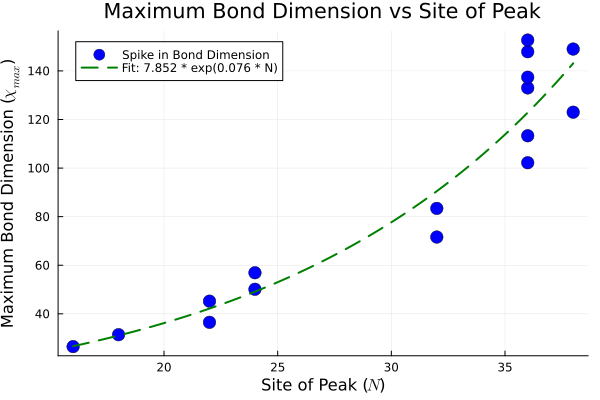

Exponential fit for varying sigma (Truncation = 1.0e-16):

Equation: χ_max = 7.8517 * exp(0.0764 * N)


In [96]:

sigs = sort([σ for σ in keys(spike_data) if σ > 0])
ns_peak = Float64[spike_data[σ].max_bd_N for σ in sigs]
bds_peak = Float64[spike_data[σ].max_bd for σ in sigs]

# 2. Perform Exponential Fit: χ = A * exp(B * N)
# Linearize: ln(χ) = ln(A) + B * N
log_bds = log.(bds_peak)
X = hcat(ns_peak, ones(length(ns_peak)))
coeffs = X \ log_bds

B = coeffs[1]
lnA = coeffs[2]
A = exp(lnA)

# Generate points for the exponential fit curve
fit_ns = range(minimum(ns_peak), maximum(ns_peak), length=100)
fit_bds = A .* exp.(B .* fit_ns)

p_exp = plot(ns_peak, bds_peak, 
    seriestype = :scatter, 
    label = "Spike in Bond Dimension", 
    markersize = 7, 
    markerstrokewidth = 0.5,
    color = :blue,
    xlabel = L"Site of Peak ($N$)", 
    ylabel = L"Maximum Bond Dimension ($\chi_{max}$)",
    title = "Maximum Bond Dimension vs Site of Peak",
    grid = true,
    legend = :topleft)

plot!(p_exp, fit_ns, fit_bds, 
    label = @sprintf("Fit: %.3f * exp(%.3f * N)", A, B), 
    linewidth = 2, 
    color = :green, 
    linestyle = :dash)

display(p_exp)

println("Exponential fit for varying sigma (Truncation = $target_trunc):\n")
@printf("Equation: χ_max = %.4f * exp(%.4f * N)\n", A, B)

# Spike trend for different truncations

In [97]:
# 1. Configuration
target_sigma = 3e-6
target_truncs = [1e-16, 1e-15, 1e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8]

function calculate_spike_truncation_data(all_data, target_sigma, target_truncs)
    spike_dict = Dict{Float64, NamedTuple{(:max_bd, :max_bd_N), Tuple{Float64, Int}}}()
    collapse_threshold = 0.85 

    for tr in target_truncs
        if haskey(all_data, tr) && haskey(all_data[tr], target_sigma)
            data = all_data[tr][target_sigma]
            bond_dims = data["avg_arr"]
            n_sites = data["N_range"]
            
            running_max_val = 0.0
            running_max_N = Int(n_sites[1])
            spike_detected = false # Flag to check if a collapse actually happened
            
            for i in 1:length(bond_dims)
                val = bond_dims[i]
                N = Int(n_sites[i])
                
                if val > running_max_val
                    running_max_val = val
                    running_max_N = N
                end
                
                # If bond dimension drops significantly, we've found a real spike
                if running_max_val > 5.0 && val < collapse_threshold * running_max_val
                    spike_detected = true
                    break
                end
            end
            
            # If no collapse was detected, we return 0 for both values
            if spike_detected
                spike_dict[tr] = (max_bd = running_max_val, max_bd_N = running_max_N)
            else
                spike_dict[tr] = (max_bd = 0.0, max_bd_N = 0)
            end
        end
    end
    return spike_dict
end

spike_trunc_data = calculate_spike_truncation_data(all_data, target_sigma, target_truncs)

# Only keep entries where a spike was actually detected (max_bd > 0)
valid_truncs = sort([tr for tr in keys(spike_trunc_data) if spike_trunc_data[tr].max_bd > 0])



3-element Vector{Float64}:
 1.0e-16
 1.0e-15
 1.0e-14

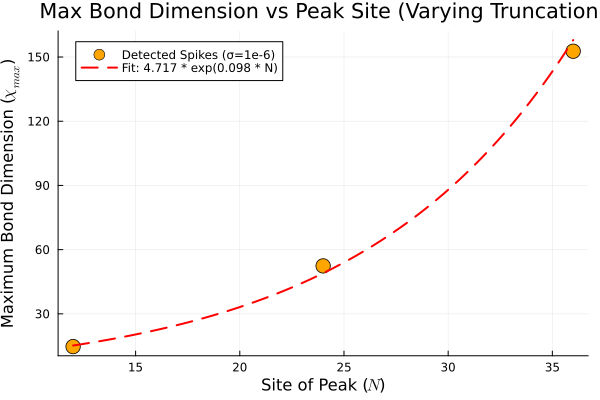

Exponential fit for varying truncation (σ=1e-6):
χ_max = 4.7167 * exp(0.0975 * N)


In [98]:

if length(valid_truncs) < 2
    println("Warning: Not enough spikes detected to perform an exponential fit.")
else
    ns_peak_tr = Float64[spike_trunc_data[tr].max_bd_N for tr in valid_truncs]
    bds_peak_tr = Float64[spike_trunc_data[tr].max_bd for tr in valid_truncs]

    # Exponential Fit: χ = A * exp(B * N)
    log_bds_tr = log.(bds_peak_tr)
    X_tr = hcat(ns_peak_tr, ones(length(ns_peak_tr)))
    coeffs_tr = X_tr \ log_bds_tr

    B_tr = coeffs_tr[1]
    A_tr = exp(coeffs_tr[2])

    # Generate fit curve
    fit_ns_tr = range(minimum(ns_peak_tr), maximum(ns_peak_tr), length=100)
    fit_bds_tr = A_tr .* exp.(B_tr .* fit_ns_tr)

    p_trunc_fit = plot(ns_peak_tr, bds_peak_tr, 
        seriestype = :scatter, 
        label = "Detected Spikes (σ=1e-6)", 
        markersize = 8, 
        color = :orange,
        xlabel = L"Site of Peak ($N$)", 
        ylabel = L"Maximum Bond Dimension ($\chi_{max}$)",
        title = "Max Bond Dimension vs Peak Site (Varying Truncation)",
        grid = true,
        legend = :topleft)

    plot!(p_trunc_fit, fit_ns_tr, fit_bds_tr, 
        label = @sprintf("Fit: %.3f * exp(%.3f * N)", A_tr, B_tr), 
        linewidth = 2, 
        color = :red, 
        linestyle = :dash)

    display(p_trunc_fit)

    @printf("Exponential fit for varying truncation (σ=1e-6):\n")
    @printf("χ_max = %.4f * exp(%.4f * N)\n", A_tr, B_tr)
end

# Spectra

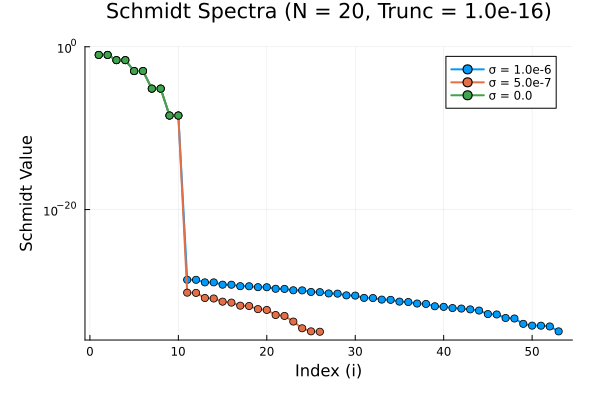

In [99]:
target_sigmas = [0.0, 5e-7, 1e-6] 
target_trunc = 1e-16
target_N = 20

p_spectra = plot(
    title = "Schmidt Spectra (N = $target_N, Trunc = $target_trunc)",
    xlabel = "Index (i)",
    ylabel = "Schmidt Value",
    legend = :topright,
    yscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for σ in sort(target_sigmas, rev=true) 
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        
        # Find the index where N is 40
        idx = findfirst(==(target_N), N_full)
        
        if !isnothing(idx)
            # Extract the spectra for N = 40 using matrix slicing [row, all_columns]
            spectra = data["spectra_avg"][idx, :]
            
            # Filter out exact zeros to avoid -Inf errors on the log10 plot
            valid_spectra = filter(x -> x > 0, spectra)
            
            # Sort the spectra in descending order (largest to smallest)
            sorted_spectra = sort(valid_spectra, rev=true).^2
            
            # Plot the sorted spectra against its index
            plot!(p_spectra, 1:length(sorted_spectra), sorted_spectra, 
                label = "σ = $(σ)", 
                marker = :circle, 
                linewidth = 2)
        else
            println("Warning: N = $target_N not found for Trunc = $target_trunc, σ = $σ")
        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_spectra)

# Entropies

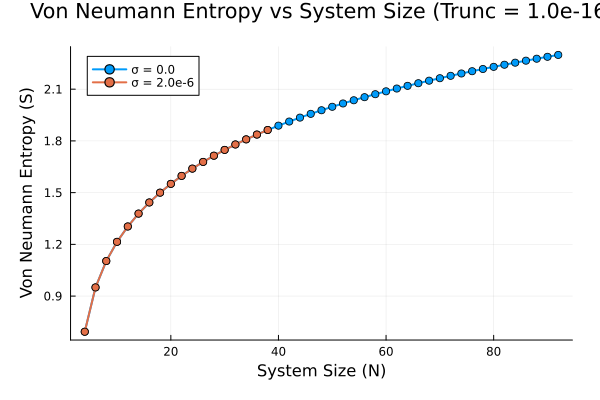

In [100]:
target_sigmas = [0.0, 2e-6] 
target_trunc = 1e-16

p_vn = plot(
    title = "Von Neumann Entropy vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Von Neumann Entropy (S)",
    legend = :topleft,    
    # xscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_range = data["N_range"]
        vn_entropy = data["vn_avg"]

        mask = vn_entropy .> 0.0
        
        valid_N = N_range[mask]
        valid_vn = vn_entropy[mask]
        
        if !isempty(valid_vn)
            plot!(p_vn, valid_N, valid_vn, 
                label = "σ = $(σ)", 
                marker = :circle, 
                linewidth = 2)

        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_vn)

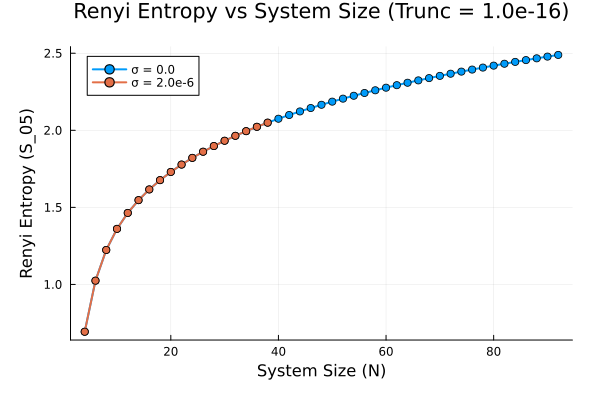

In [101]:
target_sigmas = [0.0, 2e-6] 
target_trunc = 1e-16

p_s05 = plot(
    title = "Renyi Entropy vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Renyi Entropy (S_05)",
    legend = :topleft,    
    # xscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_range = data["N_range"]
        s05_entropy = data["s05_avg"]

        mask = s05_entropy .> 0.0
        
        valid_N = N_range[mask]
        valid_ent = s05_entropy[mask]
        
        if !isempty(valid_ent)
            plot!(p_s05, valid_N, valid_ent, 
                label = "σ = $(σ)", 
                marker = :circle, 
                linewidth = 2)

        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_s05)

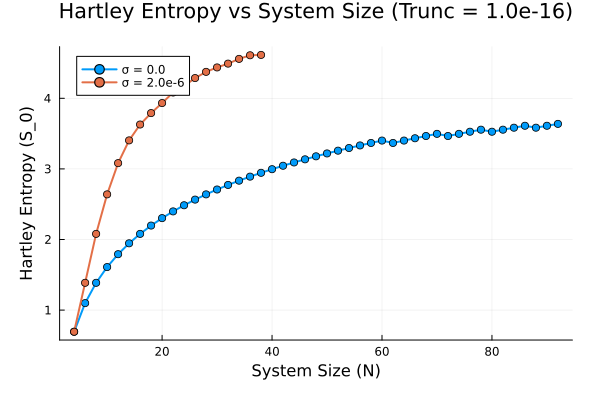

In [102]:
target_sigmas = [0.0, 2e-6] 
target_trunc = 1e-16

p_s0 = plot(
    title = "Hartley Entropy vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Hartley Entropy (S_0)",
    legend = :topleft,    
    # xscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_range = data["N_range"]
        s0_entropy = data["s0_avg"]

        mask = s0_entropy .> 0.0
        
        valid_N = N_range[mask]
        valid_ent = s0_entropy[mask]
        
        if !isempty(valid_ent)
            plot!(p_s0, valid_N, valid_ent, 
                label = "σ = $(σ)", 
                marker = :circle, 
                linewidth = 2)

        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_s0)

# Fidelity


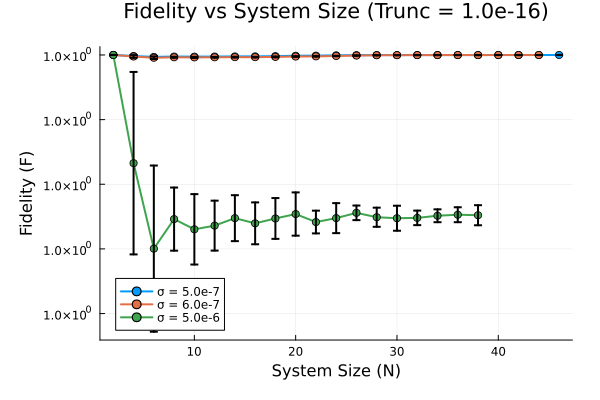

In [103]:
target_sigmas = [5e-7, 6e-7, 5e-6] 
target_trunc = 1e-16

p_fid = plot(
    title = "Fidelity vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = "Fidelity (F)",
    legend = :bottomleft,  # Moved to bottom left so it doesn't cover data near F=1
    margin = 5Plots.mm,
    grid = true
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        # We use the bond dimension > 0 as a universal mask for "completed runs"
        mask = data["avg_arr"] .> 0 
        
        N_vals = N_full[mask]
        fid_avg = data["fid_avg"][mask]
        fid_err_full = data["fid_err"]
        
        if σ == 0.0
            err_bars = nothing
        else
            err_bars = fid_err_full[mask]
        end

        plot!(p_fid, N_vals, fid_avg, 
            yerror = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_fid)


# Infidelity


In [104]:
"""
    get_infidelity_data(all_data, target_trunc, target_sigma)

Extracts system size (N), infidelity (beta), and error bars for a specific 
truncation and sigma from the loaded data dictionary.
"""
function get_infidelity_data(all_data, target_trunc, target_sigma)
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], target_sigma)
        data = all_data[target_trunc][target_sigma]
        
        # 1. Get the system size range and mask for completed runs
        # (Using avg_arr > 0 logic from your fid_analysis script)
        N_full = data["N_range"]
        mask = data["avg_arr"] .> 0 
        
        N_vals = N_full[mask]
        xi_vals = data["fid_avg"][mask] # Mean Fidelity (overlap)
        xi_errs = data["fid_err"][mask] # Error in Fidelity
        
        # 2. Calculate Infidelity beta = sqrt(1 - xi^2)
        # We use max(0, ...) to avoid tiny negative numbers due to precision
        beta_vals = sqrt.(max.(0.0, 1.0 .- xi_vals.^2))
        
        # 3. Propagate Error: delta_beta = (xi / beta) * delta_xi
        # We handle the case where beta is 0 to avoid division by zero
        beta_errs = Float64[]
        for (x, b, dx) in zip(xi_vals, beta_vals, xi_errs)
            if b > 1e-10
                push!(beta_errs, (x / b) * dx)
            else
                push!(beta_errs, 0.0) # Error is negligible or undefined at perfect fidelity
            end
        end
        
        return N_vals, beta_vals, beta_errs
    else
        @warn "Data not found for Trunc = $target_trunc, σ = $target_sigma"
        return nothing
    end
end

get_infidelity_data

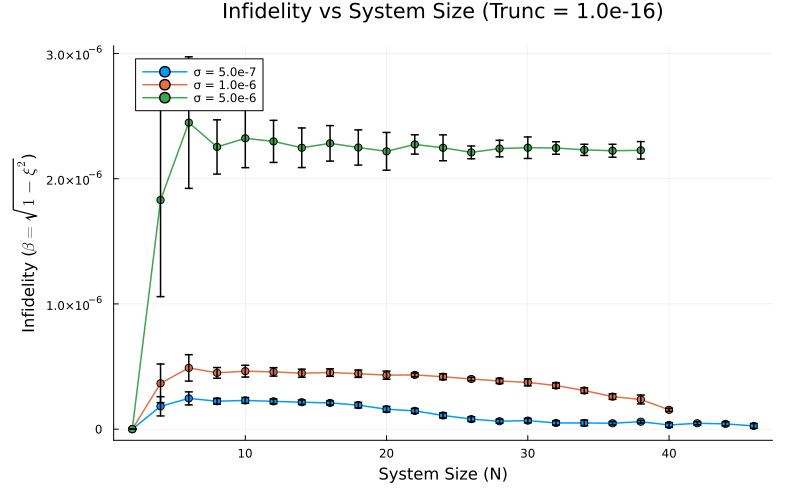

In [105]:
using Plots
using LaTeXStrings

# Parameters to plot
target_trunc = 1e-16
chosen_sigmas = [5e-7, 1e-6, 5e-6] # Adjust as needed

p_infid = plot(
    title = "Infidelity vs System Size (Trunc = $target_trunc)",
    xlabel = "System Size (N)",
    ylabel = L"Infidelity ($\beta = \sqrt{1 - \xi^2}$)",
    legend = :topleft,
    grid = true,
    size = (800, 500),
    margin = 5Plots.mm
)

for σ in chosen_sigmas
    result = get_infidelity_data(all_data, target_trunc, σ)
    if !isnothing(result)
        N_vals, beta_vals, beta_errs = result
        plot!(p_infid, N_vals, beta_vals, 
            yerror = beta_errs,
            label = "σ = $σ", 
            marker = :circle, 
            markersize = 4,
            linewidth = 1.5)
    end
end

display(p_infid)
# savefig("infidelity_vs_N.png")